In [2]:
import numpy as np
import pandas as pd
import anndata as ad
from scipy.sparse import csr_matrix
import scanpy as sc
from itertools import chain
import itertools
import networkx as nx
import scglue
import seaborn as sns
from matplotlib import rcParams
import sys
import os
print(ad.__version__)
utils_path = "C:/Users/Acer/Desktop/ST&SM Integrator"
if utils_path not in sys.path:
    sys.path.append(utils_path)
import MSTI_Guidancegraph as MG
import MSTI_preprocess as MP

0.9.2


## Alignment

In [3]:
file_path = 'C:/Users/Acer/Desktop/ST&SM Integrator/data/MT/6610-neg.txt'
meta = MP.process_mt_data(file_path)
meta_bc = meta

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


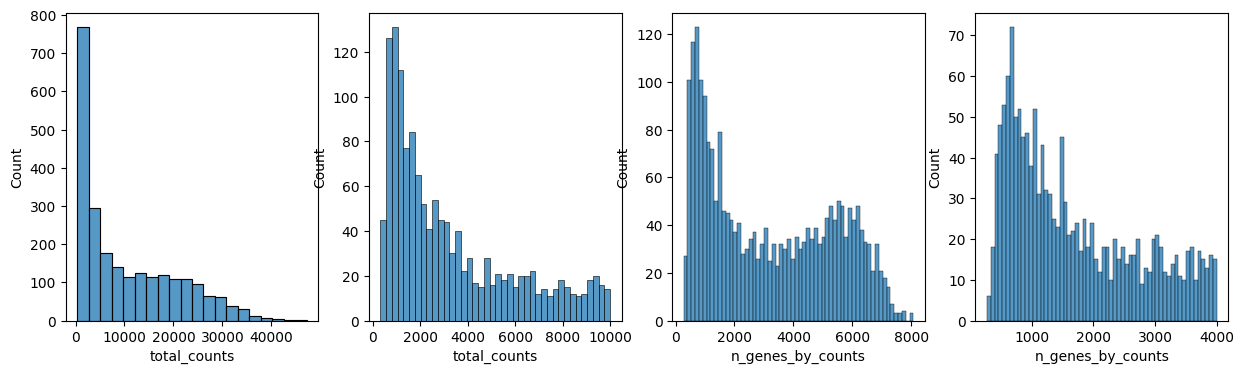

In [4]:
visium_path = 'C:/Users/Acer/Desktop/ST&SM Integrator/data/ST/NO.49129/outs'
rna = MP.process_st_data(visium_path)
rna_bc = rna

In [5]:
kegg_rna = pd.read_csv('C:/Users/Acer/Desktop/ST&SM Integrator/data/KEGG_Dataset/hsa_kegg_gene.csv')
kegg_reaction = pd.read_csv('C:/Users/Acer/Desktop/ST&SM Integrator/data/KEGG_Dataset/keggAllreaction.csv')
sample_mt = pd.read_excel('C:/Users/Acer/Desktop/ST&SM Integrator/data/KEGG_Dataset/ALL_sample_data_neg.xlsx')

In [6]:
guidance = MG.MSTI_kegg_Guidancegraph(rna, meta, kegg_reaction,sample_mt, kegg_rna)

C:\Users/Acer/Desktop/ST&SM Integrator\MSTI_Guidancegraph.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kegg_reaction['KEGG'] = kegg_reaction['KEGG'].str.split(',')


Creating KEGG reaction graph...
KEGG reaction graph completed!
Graph completed!


In [7]:
scglue.graph.check_graph(guidance, [rna, meta])

[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] check_graph: All checks passed!


In [8]:
scglue.models.configure_dataset(
    rna, "NB", use_layer="counts",use_highly_variable=True,
    use_rep="X_pca"
)
scglue.models.configure_dataset(
    meta, "NB", use_layer="counts",use_highly_variable=True,
     use_rep="X_pca"
)
guidance_hvf = guidance.subgraph(chain(
    rna.var.query("highly_variable").index,
    meta.var.query("highly_variable").index
)).copy()

In [9]:
glue = scglue.models.fit_SCGLUE(
    {"rna": rna, "meta": meta}, guidance_hvf,
    fit_kws={"directory": "glue"}
)

[INFO] fit_SCGLUE: Pretraining SCGLUE model...
[INFO] autodevice: Using GPU 0 as computation device.
[INFO] check_graph: Checking variable coverage...
[INFO] check_graph: Checking edge attributes...
[INFO] check_graph: Checking self-loops...
[INFO] check_graph: Checking graph symmetry...
[INFO] SCGLUEModel: Setting `graph_batch_size` = 1179
[INFO] SCGLUEModel: Setting `max_epochs` = 78
[INFO] SCGLUEModel: Setting `patience` = 7
[INFO] SCGLUEModel: Setting `reduce_lr_patience` = 4
[INFO] SCGLUETrainer: Using training directory: "glue\pretrain"


C:\Users\Acer\.conda\envs\clean\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.033, 'g_kl': 0.046, 'g_elbo': 0.079, 'x_rna_nll': 0.195, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.199, 'x_meta_nll': 1.077, 'x_meta_kl': 0.038, 'x_meta_elbo': 1.115, 'dsc_loss': 0.683, 'vae_loss': 1.318, 'gen_loss': 1.284}, val={'g_nll': 0.036, 'g_kl': 0.046, 'g_elbo': 0.083, 'x_rna_nll': 0.193, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.198, 'x_meta_nll': 1.058, 'x_meta_kl': 0.038, 'x_meta_elbo': 1.095, 'dsc_loss': 0.68, 'vae_loss': 1.296, 'gen_loss': 1.262}, 14.4s elapsed
[INFO] SCGLUETrainer: [Epoch 20] train={'g_nll': 0.026, 'g_kl': 0.047, 'g_elbo': 0.072, 'x_rna_nll': 0.193, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.197, 'x_meta_nll': 1.061, 'x_meta_kl': 0.04, 'x_meta_elbo': 1.102, 'dsc_loss': 0.687, 'vae_loss': 1.302, 'gen_loss': 1.267}, val={'g_nll': 0.027, 'g_kl': 0.047, 'g_elbo': 0.074, 'x_rna_nll': 0.192, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.196, 'x_meta_nll': 1.045, 'x_meta_kl': 0.04, 'x_meta_elbo': 1.084, 'dsc_loss': 0.683, 'vae_loss': 1.283, 'ge

2025-03-04 12:48:54,359 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "40"...


...

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


[INFO] SCGLUETrainer: [Epoch 10] train={'g_nll': 0.026, 'g_kl': 0.045, 'g_elbo': 0.071, 'x_rna_nll': 0.192, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.196, 'x_meta_nll': 1.056, 'x_meta_kl': 0.04, 'x_meta_elbo': 1.096, 'dsc_loss': 0.669, 'vae_loss': 1.295, 'gen_loss': 1.262}, val={'g_nll': 0.029, 'g_kl': 0.045, 'g_elbo': 0.073, 'x_rna_nll': 0.212, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.216, 'x_meta_nll': 1.042, 'x_meta_kl': 0.039, 'x_meta_elbo': 1.081, 'dsc_loss': 0.652, 'vae_loss': 1.3, 'gen_loss': 1.268}, 23.8s elapsed
[INFO] SCGLUETrainer: [Epoch 20] train={'g_nll': 0.027, 'g_kl': 0.044, 'g_elbo': 0.07, 'x_rna_nll': 0.193, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.197, 'x_meta_nll': 1.052, 'x_meta_kl': 0.04, 'x_meta_elbo': 1.093, 'dsc_loss': 0.663, 'vae_loss': 1.292, 'gen_loss': 1.259}, val={'g_nll': 0.027, 'g_kl': 0.044, 'g_elbo': 0.071, 'x_rna_nll': 0.214, 'x_rna_kl': 0.004, 'x_rna_elbo': 0.218, 'x_meta_nll': 1.038, 'x_meta_kl': 0.04, 'x_meta_elbo': 1.078, 'dsc_loss': 0.639, 'vae_loss': 1.299, 'gen_l

2025-03-04 13:06:56,285 ignite.handlers.early_stopping.EarlyStopping INFO: EarlyStopping: Stop training


[INFO] EarlyStopping: Restoring checkpoint "40"...
[INFO] EarlyStopping: Restoring checkpoint "40"...


C:\Users\Acer\.conda\envs\clean\Lib\site-packages\scglue\models\plugins.py:145: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  loaded = torch.load(directory / f"checkpoint_{c

In [10]:
rna.obsm["X_glue"] = glue.encode_data("rna", rna)
meta.obsm["X_glue"] = glue.encode_data("meta", meta)
rna.obs['domain'] = 'rna'
meta.obs['domain'] = 'meta'
combined = ad.concat([rna, meta])

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


C:\Users\Acer\.conda\envs\clean\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


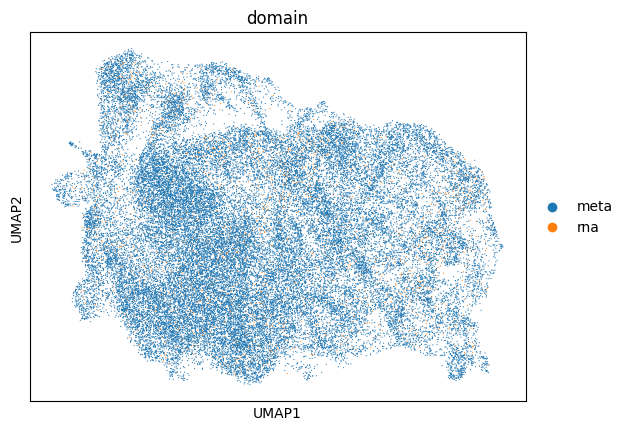

In [11]:
sc.pp.neighbors(combined, use_rep="X_glue", metric="cosine")
sc.tl.umap(combined)
sc.pl.umap(combined, color='domain', wspace=0.65)

In [12]:
rna_index = rna_bc
rna = combined[combined.obs['domain'] == 'rna']
meta = combined[combined.obs['domain'] == 'meta']
df_rna = pd.DataFrame(rna.obsm['X_glue'])
df_meta = pd.DataFrame(meta.obsm['X_glue'])
df_rna_adata = ad.AnnData(X=df_rna)
df_meta_adata = ad.AnnData(X=df_meta)
df_rna_adata.obs = pd.DataFrame(index=rna.obs.index)
df_meta_adata.obs = pd.DataFrame(index=meta.obs.index)
df_meta_adata.obs['x'] = df_meta_adata.obs.index.str.split('x').str[0]
df_meta_adata.obs['y'] = df_meta_adata.obs.index.str.split('x').str[1]
df_meta_adata.obs['array_row'] = df_meta_adata.obs['x']
df_meta_adata.obs['array_col'] = df_meta_adata.obs['y']
df_meta_adata.obs['x_spa'] = df_meta_adata.obs['x'].astype(float) * 117.6471
df_meta_adata.obs['y_spa'] = df_meta_adata.obs['y'].astype(float) * 117.6471
df_rna_adata.obs['domain'] = 'rna'
df_meta_adata.obs['domain'] = 'meta'
combined = ad.concat([df_rna_adata, df_meta_adata])

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [13]:
combined.var_names_make_unique()
combined.layers["counts"] = combined.X.copy()
sc.pp.neighbors(combined)
sc.tl.umap(combined)

In [14]:
sc.tl.louvain(
    combined,
    resolution=0.15,
    random_state=0,

    key_added='louvain',
    directed=False,
)

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


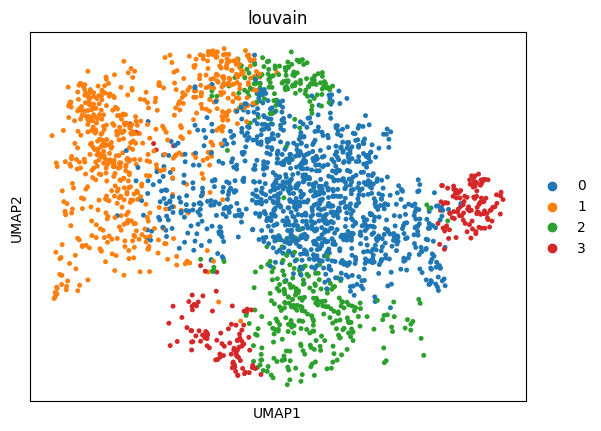

C:\Users\Acer\.conda\envs\clean\Lib\site-packages\anndata\_core\anndata.py:1230: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
C:\Users\Acer\.conda\envs\clean\Lib\site-packages\scanpy\plotting\_tools\scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


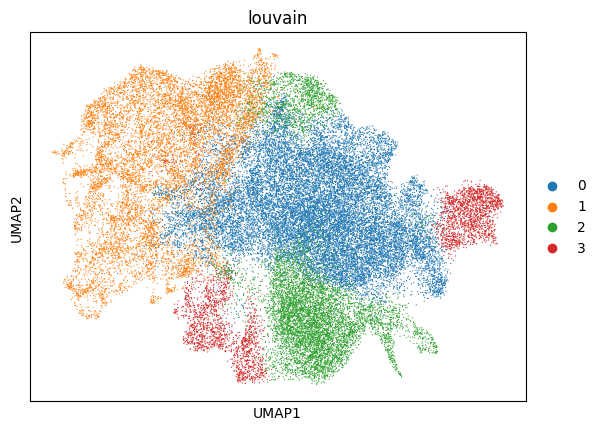

In [15]:
domain_rna = combined[combined.obs['domain'] == 'rna']
sc.pl.umap(domain_rna, color='louvain')
domain_meta = combined[combined.obs['domain'] == 'meta']
sc.pl.umap(domain_meta, color='louvain')

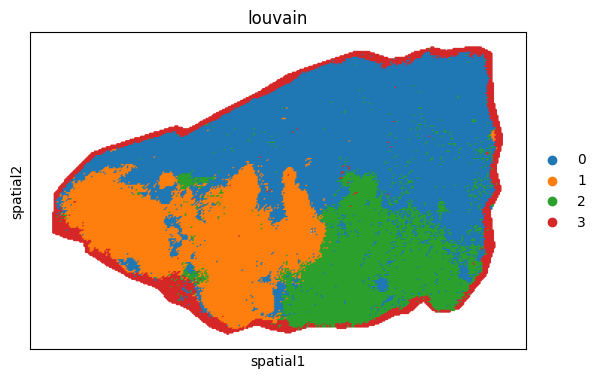

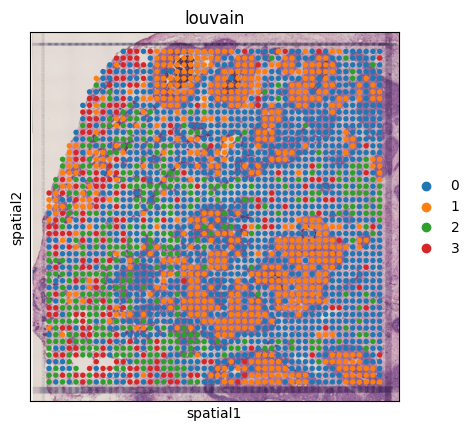

In [16]:
meta_spa = meta_bc
rna_spa = rna_bc
meta_spa.obs['louvain'] = domain_meta.obs['louvain']
sc.pl.spatial(meta_spa, color="louvain", spot_size=2)
rna_spa.obs['louvain'] = domain_rna.obs['louvain']
sc.pl.spatial(rna_spa, color="louvain",size=0.8)

In [17]:
# combined.write_h5ad('DCIS.h5ad')
# glue.save("DCIS.dill")